In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    train_test_split
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Análise de atributos

Não está sendo uma EDA ou preprocessing propriamente dito, mas faz um tratamento e análise básica do estado do dataset.

In [3]:
# Dropando features desnecessárias para a predição
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"]) 

In [4]:
# Modificando os nomes das colunas
df.columns = ["survived", "class", "sex", "age", "siblingSpouse", "parentChildren", "fare", "port"]

In [5]:
# Verifica quais valores estão faltantes
df.isna().sum()

survived            0
class               0
sex                 0
age               177
siblingSpouse       0
parentChildren      0
fare                0
port                2
dtype: int64

In [6]:
# Imputação/remoção de dados
df['age'] = df['age'].fillna(df['age'].median())
df.dropna(inplace=True)

In [7]:
# Encoding
encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[['sex', 'port', 'class']])
encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(['sex', 'port', 'class']),
    index=df.index
)

df = pd.concat([df.drop(columns=['sex', 'port', 'class']), encoded_df], axis=1)

### Treinamento

In [8]:
X = df.drop(columns='survived')
Y = df['survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [10]:
# Validação cruzada e treinamento do modelo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    estimator=pipeline,
    X=X_train,
    y=Y_train,
    cv=cv,
    scoring='f1'
)

pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','siblingSpouse','parentChildren',...,'class_1','class_2','class_3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Inferência

In [11]:
predictions = pipeline.predict(X_test)

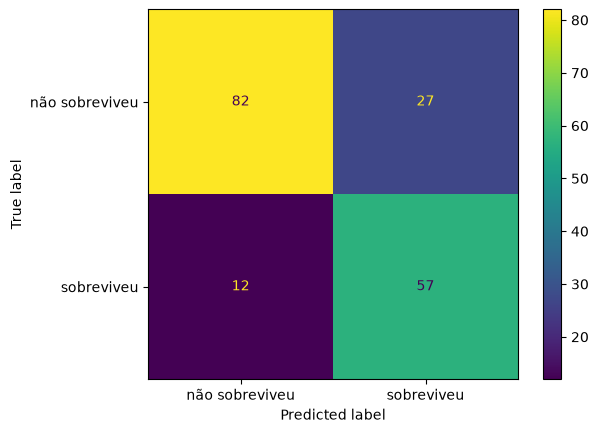

In [12]:

cm = confusion_matrix(Y_test, predictions)

ConfusionMatrixDisplay(
    cm,
    display_labels=['não sobreviveu', 'sobreviveu'],
).plot()

In [13]:
print(classification_report(Y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.75      0.81       109
           1       0.68      0.83      0.75        69

    accuracy                           0.78       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.78      0.78       178



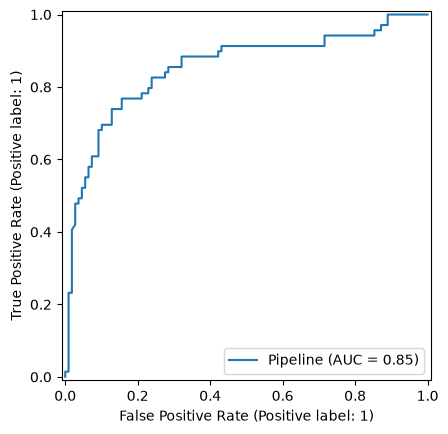

In [14]:
RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    Y_test
)

In [15]:
import numpy as np

coefs = pipeline.named_steps['model'].coef_[0]
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coefs,
    'Odds Ratio': np.exp(coefs)
})

df_importance['Abs_Coef'] = df_importance['Coeficiente'].abs()
df_importance = df_importance.sort_values(by=['Odds Ratio', 'Abs_Coef'], ascending=False).drop(columns='Coeficiente')

df_importance

,Feature,Odds Ratio,Abs_Coef
4,sex_female,1.878077,0.630249
9,class_1,1.638487,0.493773
3,fare,1.127853,0.120316
6,port_C,1.123642,0.116575
10,class_2,1.079550,0.076544
7,port_Q,1.028623,0.028221
2,parentChildren,0.937516,0.064521
8,port_S,0.887407,0.119451
1,siblingSpouse,0.638103,0.449255
11,class_3,0.615034,0.486078
